In [2]:
import pandas as pd

df = pd.read_csv('cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
print(df.shape)
print(df['version'].value_counts())
df.info()

(90189, 5)
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


## Hypothesis
The game's first gate (a mandatory wait/purchase point) was originally at level 30.
This experiment tests moving the gate to level 40 instead.

**Null hypothesis (H0):** Moving the gate from level 30 to level 40 has no effect on player retention.
**Alternative hypothesis (H1):** Moving the gate has a significant effect on player retention.

We'll test this on two metrics: 1-day retention and 7-day retention.

In [6]:
retention_summary = df.groupby('version')[['retention_1', 'retention_7']].mean()
print(retention_summary)

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


In [7]:
from scipy.stats import chi2_contingency

# 1-day retention test
contingency_1 = pd.crosstab(df['version'], df['retention_1'])
chi2_1, p_value_1, dof_1, expected_1 = chi2_contingency(contingency_1)
print("1-Day Retention Test")
print(contingency_1)
print(f"Chi-square statistic: {chi2_1:.4f}")
print(f"P-value: {p_value_1:.4f}")
print()

# 7-day retention test
contingency_7 = pd.crosstab(df['version'], df['retention_7'])
chi2_7, p_value_7, dof_7, expected_7 = chi2_contingency(contingency_7)
print("7-Day Retention Test")
print(contingency_7)
print(f"Chi-square statistic: {chi2_7:.4f}")
print(f"P-value: {p_value_7:.4f}")

1-Day Retention Test
retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119
Chi-square statistic: 3.1591
P-value: 0.0755

7-Day Retention Test
retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279
Chi-square statistic: 9.9591
P-value: 0.0016


## Conclusion & Recommendation

- **1-day retention**: No statistically significant difference between gate_30 and gate_40 (p = 0.0755).
  We cannot conclude the gate placement affects short-term retention.

- **7-day retention**: Statistically significant difference (p = 0.0016). Players in the gate_40 group
  had lower 7-day retention (18.2%) than gate_30 (19.0%).

**Recommendation:** Do not move the gate from level 30 to level 40. While there's no clear short-term
impact, the statistically significant drop in 7-day retention suggests the later gate placement may
hurt longer-term player engagement. Keeping the gate at level 30 is the safer choice based on this data.

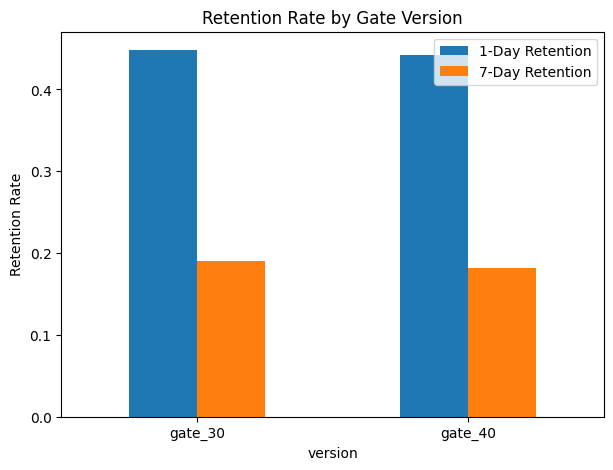

In [8]:
import matplotlib.pyplot as plt

retention_summary.plot(kind='bar', figsize=(7,5))
plt.title('Retention Rate by Gate Version')
plt.ylabel('Retention Rate')
plt.xticks(rotation=0)
plt.legend(['1-Day Retention', '7-Day Retention'])
plt.show()